# The Attention Economy: How Doomscrolling Affects Student Productivity

### A data analysis project using SQL, Python, and behavioral insights

## Project Objective

This project explores how screen habits, digital behavior, and notification patterns relate to productivity and attention span.

The goal is to understand whether behaviors associated with "doomscrolling" are linked to lower productivity or reduced focus.

## Tools Used

- SQLite for data cleaning and transformation  
- Python (Pandas + Matplotlib) for analysis and visualization  
- Jupyter Notebook for reporting  
- Tableau for dashboard design  


## Data Loading

The dataset was cleaned in SQLite and exported as a CSV file. It is loaded below for analysis.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/screen_time_final.csv")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10

In [37]:
df.shape
df.columns

Index(['age_group', 'gender', 'education_level', 'occupation',
       'average_screen_time', 'device', 'screen_activity', 'app_category',
       'screen_time_period', 'environment', 'productivity', 'attention_span',
       'work_strategy', 'notification_handling', 'usage_of_productivity_apps',
       'screen_time_group'],
      dtype='str')

In [38]:
df.head()

,age_group,gender,education_level,occupation,average_screen_time,device,screen_activity,app_category,screen_time_period,environment,productivity,attention_span,work_strategy,notification_handling,usage_of_productivity_apps,screen_time_group
0,18–24,Male,Undergraduate,Student,More than 10,Smartphone,"Entertainment (gaming, streaming, social media...","Social Media (e.g., Facebook, Instagram, Linke...",Evening (6 PM–10 PM),Quite workplace,Moderately productive,10–30 minutes,Take regular breaks,Check them briefly and resume my work,"Yes, but i did not find them of any help",High
1,18–24,Male,Undergraduate,Professional,8-10,Smartphone,"Entertainment (gaming, streaming, social media...","Streaming (e.g., YouTube, Netflix)",Late night (10 PM–6 AM),Quite workplace,Moderately productive,More than 1 hour,"None, i prefer to work without any strategies",Ignore them until my task is completed,"No, i do not use them",High
2,45 and above,Female,Graduate,Professional,4–6,Smartphone,Academic/Work-related,"Social Media (e.g., Facebook, Instagram, Linke...",Afternoon (12 PM–6 PM),I can work in any environment,Moderately productive,10–30 minutes,Take regular breaks,Check them briefly and resume my work,"No, i do not use them",Moderate
3,25–34,Male,Undergraduate,Professional,8-10,Laptop/PC,Academic/Work-related,"Social Media (e.g., Facebook, Instagram, Linke...",Afternoon (12 PM–6 PM),Quite workplace,"Extremely productive, i efficiently complete m...",10–30 minutes,"None, i prefer to work without any strategies",Ignore them until my task is completed,"No, i do not use them",High
4,45 and above,Male,Graduate,Professional,8-10,Laptop/PC,Academic/Work-related,"Productivity (e.g., Microsoft Office, Notion)",Afternoon (12 PM–6 PM),I can work in any environment,"Extremely productive, i efficiently complete m...",30–60 minutes,"None, i prefer to work without any strategies",Check them briefly and resume my work,"No, i do not use them",High


## Data Overview

The dataset contains survey responses related to:
- average screen time
- productivity
- attention span
- screen activity
- notification handling

## Visualization 1: Productivity by Screen Time Group

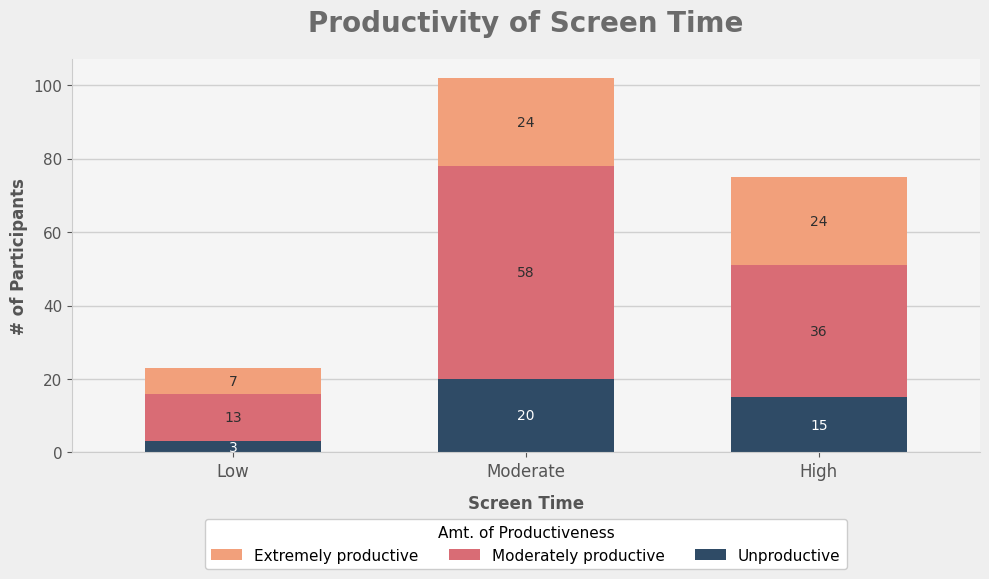

In [39]:
df_chart1 = df.copy()

df_chart1["productivity"] = df_chart1["productivity"].replace({
    "Extremely productive, i efficiently complete my tasks": "Extremely productive",
    "Moderately productive": "Moderately productive",
    "Unproductive, i might not have completed the task and got carried away": "Unproductive"
})

screen_order = ["Low", "Moderate", "High"]
productivity_order = ["Unproductive", "Moderately productive", "Extremely productive"]

chart1 = pd.crosstab(df_chart1["screen_time_group"], df_chart1["productivity"])
chart1 = chart1.reindex(screen_order)
chart1 = chart1[productivity_order]

colors = ["#2F4B66", "#D96C75", "#F2A07B"]

fig, ax = plt.subplots(figsize=(10,6), facecolor="#efefef")

chart1.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.6)

ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", color="#d0d0d0", linewidth=1)
ax.set_axisbelow(True)

ax.set_title("Productivity of Screen Time", fontsize=20, weight="bold", color="#6b6b6b", pad=20)
ax.set_xlabel("Screen Time", fontsize=12, weight="bold", color="#555555", labelpad=10)
ax.set_ylabel("# of Participants", fontsize=12, weight="bold", color="#555555")

ax.tick_params(axis="x", labelrotation=0, labelsize=12, colors="#555555")
ax.tick_params(axis="y", labelsize=11, colors="#555555")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Amt. of Productiveness",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=1,
    fontsize=11,
    title_fontsize=11
)

for i, container in enumerate(ax.containers):
    label_color = "white" if i < 1 else "#2f2f2f"
    ax.bar_label(container, label_type="center", fontsize=10, color=label_color)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.savefig("../visuals/1_productivity_of_screen_time.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Participants in the High screen time group appeared more likely to report lower productivity levels than those in the Low screen time group.

This suggests that heavier screen use may be associated with lower perceived productivity, although the relationship is correlational rather than causal.

## Visualization 2: Attention Span by Screen Activity

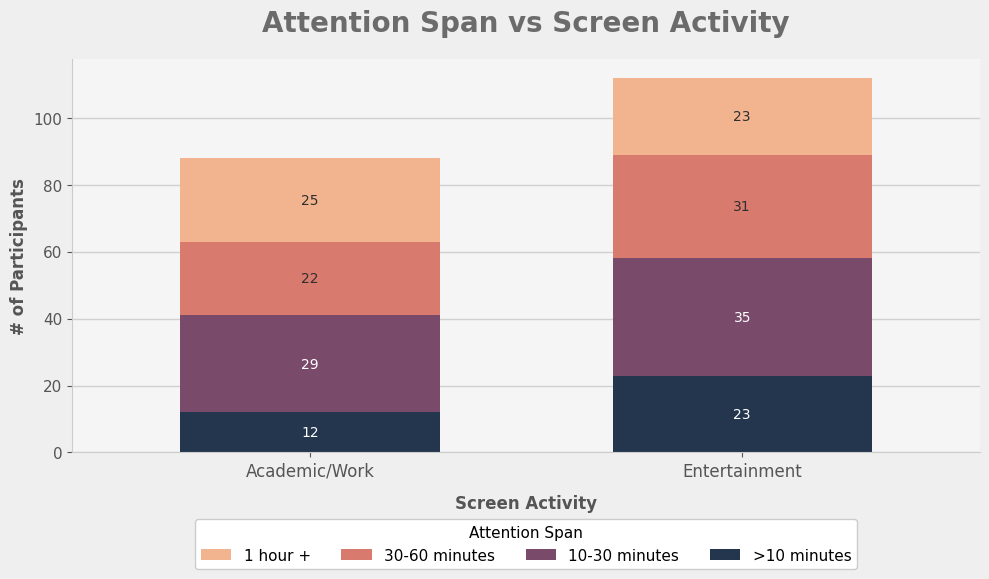

In [40]:
df_chart2 = df.copy()

df_chart2["screen_activity"] = df_chart2["screen_activity"].replace({
    "Academic/Work-related": "Academic/Work",
    "Entertainment (gaming, streaming, social media, etc.)": "Entertainment"
})

df_chart2["attention_span"] = df_chart2["attention_span"].replace({
    "Less than 10 minutes": ">10 minutes",
    "10-30 minutes": "10-30 minutes",
    "10–30 minutes": "10-30 minutes",
    "30-60 minutes": "30-60 minutes",
    "30–60 minutes": "30-60 minutes",
    "More than 1 hour": "1 hour +",
    "1 hour or more": "1 hour +"
})

activity_order = ["Academic/Work", "Entertainment"]
attention_order = [">10 minutes", "10-30 minutes", "30-60 minutes", "1 hour +"]

chart2 = pd.crosstab(df_chart2["screen_activity"], df_chart2["attention_span"])
chart2 = chart2.reindex(activity_order)
chart2 = chart2[attention_order]

colors = ["#23364D", "#7A4A6A", "#D97A6E", "#F2B38F"]

fig, ax = plt.subplots(figsize=(10,6), facecolor="#efefef")

chart2.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.6)

ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", color="#d0d0d0", linewidth=1)
ax.set_axisbelow(True)

ax.set_title("Attention Span vs Screen Activity", fontsize=20, weight="bold", color="#6b6b6b", pad=20)
ax.set_xlabel("Screen Activity", fontsize=12, weight="bold", color="#555555", labelpad=10)
ax.set_ylabel("# of Participants", fontsize=12, weight="bold", color="#555555")

ax.tick_params(axis="x", labelrotation=0, labelsize=12, colors="#555555")
ax.tick_params(axis="y", labelsize=11, colors="#555555")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Attention Span",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=1,
    fontsize=11,
    title_fontsize=11
)

for i, container in enumerate(ax.containers):
    label_color = "white" if i < 2 else "#2f2f2f"
    ax.bar_label(container, label_type="center", fontsize=10, color=label_color)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.savefig("../visuals/2_attention_span_vs_screen_activity.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Participants in the High screen time group appeared more likely to report lower productivity levels than those in the Low screen time group.

This suggests that heavier screen use may be associated with lower perceived productivity, although the relationship is correlational rather than causal.

## Visualization 3: Notification Handling vs Productivity

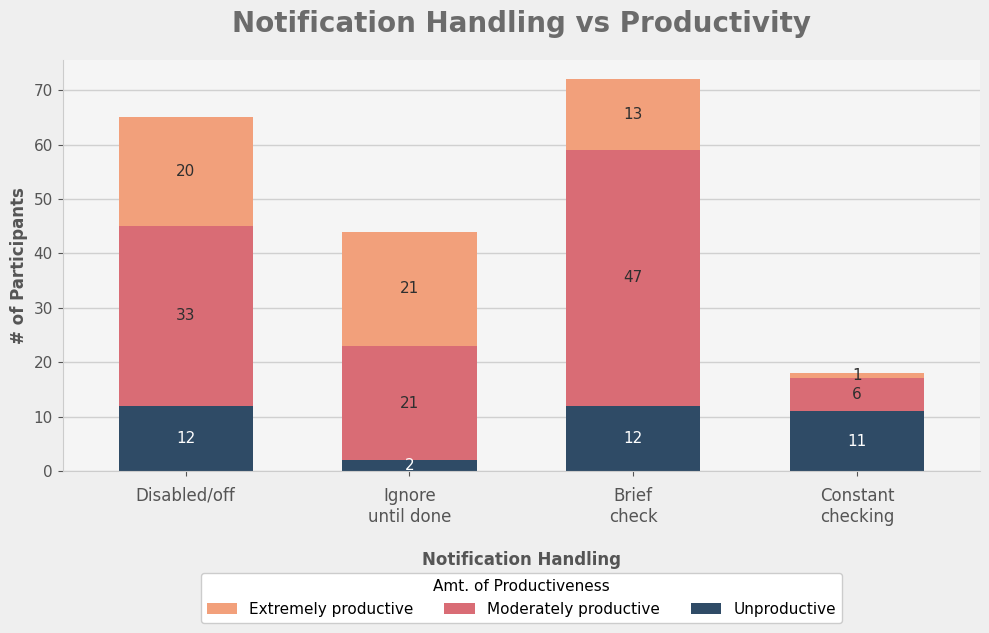

In [41]:
df_chart3 = df.copy()

df_chart3["productivity"] = df_chart3["productivity"].replace({
    "Extremely productive, i efficiently complete my tasks": "Extremely productive",
    "Moderately productive": "Moderately productive",
    "Unproductive, i might not have completed the task and got carried away": "Unproductive"
})

df_chart3["notification_handling"] = df_chart3["notification_handling"].replace({
    "Turn off notifications altogether": "Disabled/off",
    "Ignore them until my task is completed": "Ignore until done",
    "Check them briefly and resume my work": "Brief check",
    "Spend time interacting with the notifications": "Constant checking"
})

df_chart3 = df_chart3.dropna(subset=["notification_handling", "productivity"])

notif_order = ["Disabled/off", "Ignore until done", "Brief check", "Constant checking"]
productivity_order = ["Unproductive", "Moderately productive", "Extremely productive"]

chart3 = pd.crosstab(df_chart3["notification_handling"], df_chart3["productivity"])
chart3 = chart3.reindex(notif_order, fill_value=0)
chart3 = chart3.reindex(columns=productivity_order, fill_value=0)

colors = ["#2F4B66", "#D96C75", "#F2A07B"]

fig, ax = plt.subplots(figsize=(10,7), facecolor="#efefef")

chart3.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.6)

ax.set_facecolor("#f5f5f5")
ax.grid(axis="y", color="#d0d0d0", linewidth=1)
ax.set_axisbelow(True)

ax.set_title("Notification Handling vs Productivity", fontsize=20, weight="bold", color="#6b6b6b", pad=20)
ax.set_xlabel("Notification Handling", fontsize=12, weight="bold", color="#555555", labelpad=18)
ax.set_ylabel("# of Participants", fontsize=12, weight="bold", color="#555555")

ax.set_xticklabels(["Disabled/off", "Ignore\nuntil done", "Brief\ncheck", "Constant\nchecking"])

ax.tick_params(axis="x", labelrotation=0, labelsize=12, colors="#555555", pad=8)
ax.tick_params(axis="y", labelsize=11, colors="#555555")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Amt. of Productiveness",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.23),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=1,
    fontsize=11,
    title_fontsize=11
)

for i, container in enumerate(ax.containers):
    label_color = "white" if i == 0 else "#2f2f2f"
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=11, color=label_color)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig("../visuals/3_notifications_handling_vs_productivity.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Notification handling patterns appeared to align with productivity outcomes, suggesting that frequent interruptions may play a role in reduced focus.

This supports the idea that digital distractions can impact attention and productivity.

## Final Insights

Three broad patterns emerged from the analysis:

1. Higher screen time groups appeared more likely to report lower productivity
2. Attention span varied across screen activity type
3. Notification habits appeared linked to productivity outcomes

From a behavioral economics perspective, this project suggests that attention functions as a scarce resource. Digital behavior may create opportunity costs by shifting time and focus away from more productive tasks.